In [24]:
import numpy as np
!pip install qiskit
from qiskit import QuantumCircuit
from scipy.optimize import minimize
!pip install pylatexenc

In [25]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize
from sklearn.datasets import load_iris

In [26]:
# =========================
# 1. Load dataset
# =========================
data = load_iris()
X = data.data
y = data.target

In [27]:
# Alegem doar:
# petal length (index 2) si petal width (index 3)
mask = (y == 0) | (y == 2)
X = X[mask]
y = y[mask]

In [28]:
# Binary classification: setosa vs rest
y = np.where(y == 0, 1, -1)

In [29]:
# =========================
# 2. Normalize [0, 1]
# =========================
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X = (X - X_min) / (X_max - X_min)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

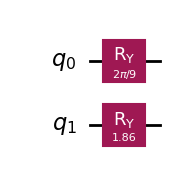

In [31]:
# =========================
# 3. Encoding
# =========================
def encode(x):
    qc = QuantumCircuit(2)
    qc.ry(np.pi * x[0], 0)
    qc.ry(np.pi * x[1], 1)
    return qc
# Desen encode pentru un exemplu
qc_encode = encode(X[0])
qc_encode.draw(output="mpl")

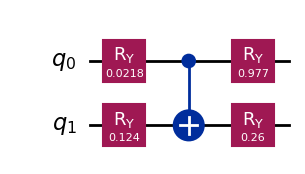

In [32]:
def ansatz(theta):
    qc = QuantumCircuit(2)

    qc.ry(theta[0], 0)
    qc.ry(theta[1], 1)

    qc.cx(0, 1)

    qc.ry(theta[2], 0)
    qc.ry(theta[3], 1)

    return qc

theta_demo = np.random.rand(4)

qc_ansatz = ansatz(theta_demo)
qc_ansatz.draw(output="mpl")


In [33]:
# =========================
# 5. Build circuit
# =========================
def build_circuit(x, theta):
    qc = QuantumCircuit(2)
    qc.compose(encode(x), inplace=True)
    qc.compose(ansatz(theta), inplace=True)
    return qc

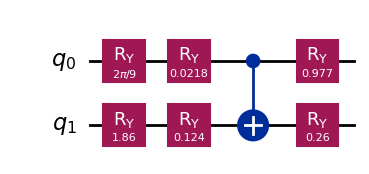

In [34]:
qc_full = build_circuit(X[0], theta_demo)
qc_full.draw(output="mpl")

In [35]:
# =========================
# 6. Forward pass
# =========================
def forward(x, theta):
    qc = build_circuit(x, theta)
    state = Statevector.from_instruction(qc)

    # Z expectation pe qubit 0
    return float(np.real(state.expectation_value([[1, 0], [0, -1]], [0])))

In [36]:
# =========================
# 7. Loss
# =========================
def loss(theta, X, y):
    preds = np.array([forward(xi, theta) for xi in X])
    return np.mean((preds - y) ** 2)

In [37]:
# =========================
# 8. Train
# =========================
theta0 = np.random.rand(4)

result = minimize(loss, np.random.rand(4), args=(X_train, y_train), method='COBYLA')
theta_opt = result.x

print("Optimized theta:", theta_opt)
print("Final loss:", result.fun)


Optimized theta: [0.33154334 1.66261086 0.51509808 1.301262  ]
Final loss: 0.18320218815002873


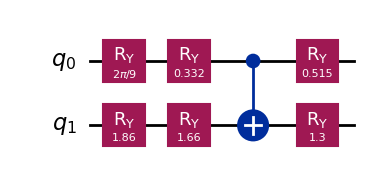

In [38]:
qc_trained = build_circuit(X[0], theta_opt)
qc_trained.draw(output="mpl")

In [39]:
pred_labels_test = np.array([
    1 if forward(x, theta_opt) >= 0 else -1
    for x in X_test
])

accuracy_test = np.mean(pred_labels_test == y_test)

print("Test Accuracy:", accuracy_test)

Test Accuracy: 1.0


In [40]:
pred_labels_train = np.array([
    1 if forward(x, theta_opt) >= 0 else -1
    for x in X_train
])

accuracy_train = np.mean(pred_labels_train == y_train)

print("Train Accuracy:", accuracy_train)

Train Accuracy: 0.9875


In [42]:
indices = np.random.choice(len(X), 10, replace=False)

for i in indices:
    pred = forward(X[i], theta_opt)

    p_setosa = (pred + 1) / 2
    p_rest = 1 - p_setosa

    label = 1 if pred >= 0 else -1

    print(f"x={X[i]}")
    print(f"raw_pred={pred:.4f}")
    print(f"P(setosa)={p_setosa:.3f}, P(rest)={p_rest:.3f}")
    print(f"true={y[i]}, predicted={label}")
    print("-" * 40)

x=[0.16666667 0.63636364 0.06779661 0.        ]
raw_pred=0.7558
P(setosa)=0.878, P(rest)=0.122
true=1, predicted=1
----------------------------------------
x=[0.52777778 0.27272727 0.6440678  0.70833333]
raw_pred=-0.6162
P(setosa)=0.192, P(rest)=0.808
true=-1, predicted=-1
----------------------------------------
x=[0.19444444 0.63636364 0.06779661 0.04166667]
raw_pred=0.7097
P(setosa)=0.855, P(rest)=0.145
true=1, predicted=1
----------------------------------------
x=[0.41666667 0.81818182 0.03389831 0.04166667]
raw_pred=0.3754
P(setosa)=0.688, P(rest)=0.312
true=1, predicted=1
----------------------------------------
x=[0.22222222 0.59090909 0.06779661 0.04166667]
raw_pred=0.6039
P(setosa)=0.802, P(rest)=0.198
true=1, predicted=1
----------------------------------------
x=[0.22222222 0.68181818 0.08474576 0.125     ]
raw_pred=0.7081
P(setosa)=0.854, P(rest)=0.146
true=1, predicted=1
----------------------------------------
x=[0.19444444 0.36363636 0.10169492 0.04166667]
raw_pred=0.37

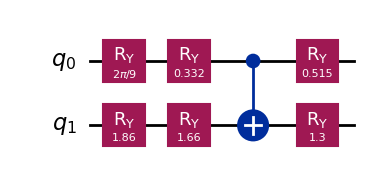

In [43]:
# =========================
# 11. Draw circuits (optional)
# =========================
# Necesita matplotlib + pylatexenc

# Encode
qc_encode = encode(X[0])
qc_encode.draw(output="mpl")

# Ansatz
theta_demo = np.random.rand(4)
qc_ansatz = ansatz(theta_demo)
qc_ansatz.draw(output="mpl")

# Full circuit (trained)
qc_full = build_circuit(X[0], theta_opt)
qc_full.draw(output="mpl")